In [1]:
import pandas as pd

In [2]:
data = pd.read_csv(r'C:\Users\gurus\OneDrive\Desktop\study\project\3rd project\youtube_ad_revenue_dataset.csv')
data.shape
data.head(5)
df = data.copy()
df.head(5)

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [3]:
# missing value 
df.isnull().sum()

video_id                   0
date                       0
views                      0
likes                   6117
comments                6112
watch_time_minutes      6105
video_length_minutes       0
subscribers                0
category                   0
device                     0
country                    0
ad_revenue_usd             0
dtype: int64

In [4]:
# data type 
df.dtypes

video_id                 object
date                     object
views                     int64
likes                   float64
comments                float64
watch_time_minutes      float64
video_length_minutes    float64
subscribers               int64
category                 object
device                   object
country                  object
ad_revenue_usd          float64
dtype: object

In [5]:
#description
df.describe()

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000000,116283.000000,116288.000000,116295.000000,122400.000000,122400.000000,122400.000000
mean,9999.856283,1099.633618,274.396636,37543.827721,16.014165,502191.719902,252.727210
std,99.881260,519.424089,129.741739,12987.724246,8.083790,288397.470103,61.957052
min,9521.000000,195.000000,48.000000,14659.105562,2.000142,1005.000000,126.590603
25%,9933.000000,650.000000,162.000000,26366.320569,9.004695,252507.500000,199.902018
50%,10000.000000,1103.000000,274.000000,37531.990337,16.005906,503465.500000,252.749699
75%,10067.000000,1547.000000,387.000000,48777.782090,23.021260,752192.000000,305.597518
max,10468.000000,2061.000000,515.000000,61557.670089,29.999799,999997.000000,382.768254


In [6]:
df['likes'] = df['likes'].fillna(df.groupby('category')['likes'].transform('mean'))
df['comments'] = df['comments'].fillna(df.groupby(['category','country','device'])['comments'].transform('mean'))
df['watch_time_minutes'] = df['watch_time_minutes'].fillna(df.groupby(['category','country','device'])['watch_time_minutes'].transform('mean'))

In [7]:
df['likes'].dtype
df['likes'].isnull().sum()

0

In [8]:
df.isnull().sum()

video_id                0
date                    0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
dtype: int64

In [9]:
df['date'] = pd.to_datetime(df['date'])
df['date'].dtype
df.date.head(5)

0   2024-09-24 10:50:40.993199
1   2024-09-22 10:50:40.993199
2   2024-11-21 10:50:40.993199
3   2025-01-28 10:50:40.993199
4   2025-04-28 10:50:40.993199
Name: date, dtype: datetime64[ns]

In [10]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['quarter'] = df['date'].dt.quarter

In [11]:
df.drop(['video_id','date'],axis = 1,inplace = True)

In [12]:
df.head(2)

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,year,month,day,quarter
0,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,2024,9,24,3
1,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,2024,9,22,3


In [13]:
df.dtypes

views                     int64
likes                   float64
comments                float64
watch_time_minutes      float64
video_length_minutes    float64
subscribers               int64
category                 object
device                   object
country                  object
ad_revenue_usd          float64
year                      int32
month                     int32
day                       int32
quarter                   int32
dtype: object

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

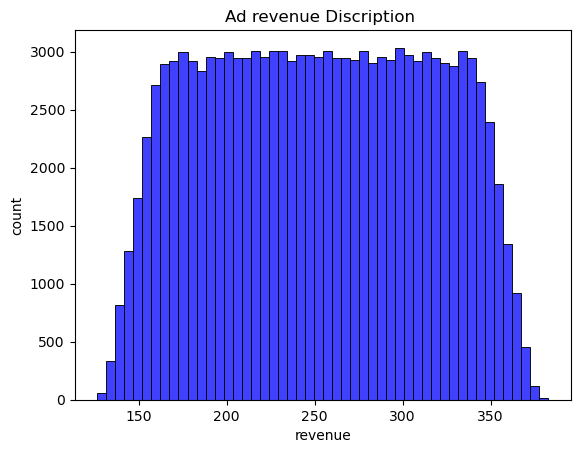

In [15]:
sns.histplot(df['ad_revenue_usd'],bins=50,color='blue')
plt.title('Ad revenue Discription ')
plt.xlabel('revenue')
plt.ylabel("count")
plt.show()

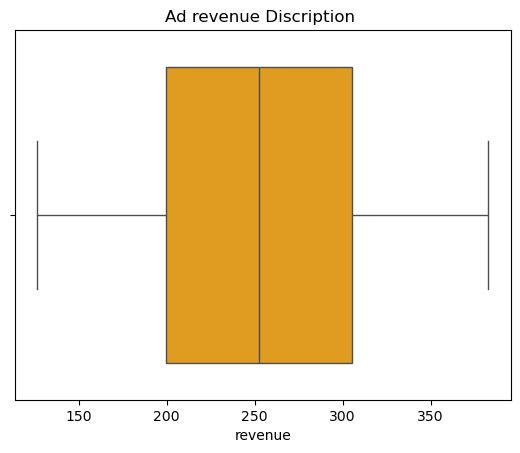

In [16]:
sns.boxplot(x=df['ad_revenue_usd'],color='orange')
plt.title('Ad revenue Discription ')
plt.xlabel('revenue')
plt.show()

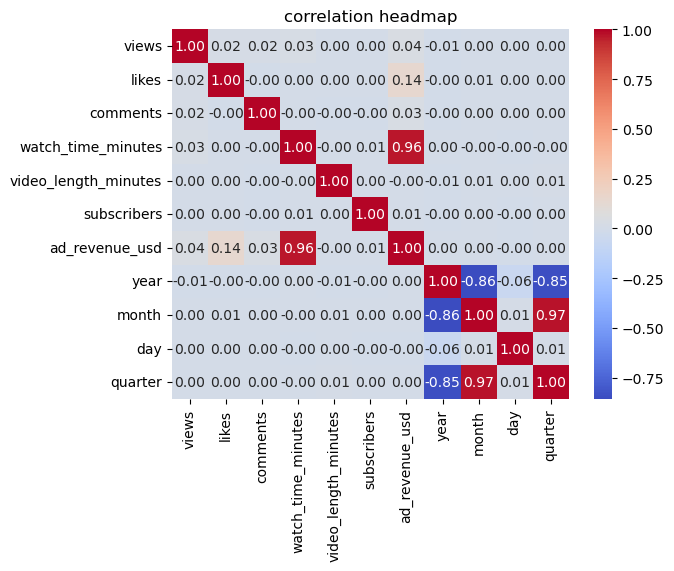

In [17]:
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt='.2f',cmap='coolwarm')
plt.title('correlation headmap')
plt.show()

In [18]:
df.drop(columns=['quarter'], inplace=True)

In [19]:
df['watch_revenue_interaction'] = df['watch_time_minutes'] * df['ad_revenue_usd']

In [20]:
df['like_rate'] = df['likes'] / (df['views'] + 1)

In [21]:
import numpy as np
for col in ['views', 'likes', 'comments', 'ad_revenue_usd']:
    df[f'log_{col}'] = np.log1p(df[col])

In [22]:
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

C:\Users\gurus\AppData\Local\Temp\ipykernel_17400\1121156542.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_rev.index,y=cat_rev.values,palette='viridis')


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Gaming'),
  Text(1, 0, 'Tech'),
  Text(2, 0, 'Music'),
  Text(3, 0, 'Education'),
  Text(4, 0, 'Entertainment'),
  Text(5, 0, 'Lifestyle')])

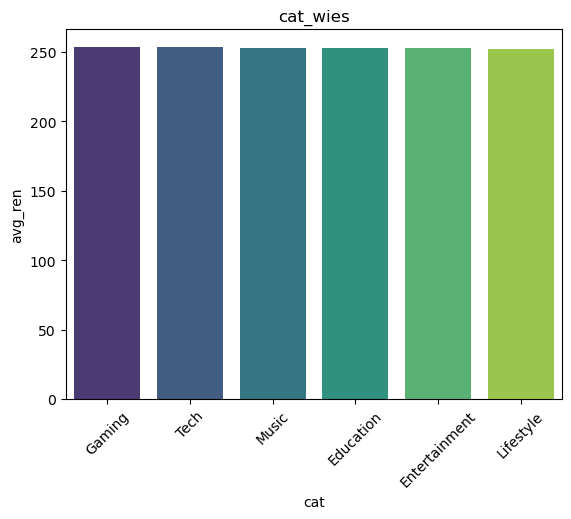

In [23]:
cat_rev = df.groupby('category')['ad_revenue_usd'].mean().sort_values(ascending=False)
sns.barplot(x=cat_rev.index,y=cat_rev.values,palette='viridis')
plt.title("cat_wies")
plt.xlabel('cat')
plt.ylabel('avg_ren')
plt.xticks(rotation =45)

C:\Users\gurus\AppData\Local\Temp\ipykernel_17400\993466302.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_rev.index,y=cat_rev.values,palette='viridis')


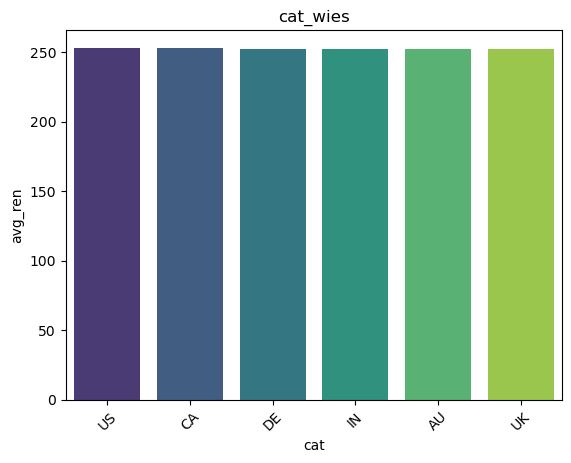

In [24]:
cat_rev = df.groupby('country')['ad_revenue_usd'].mean().sort_values(ascending=False)
sns.barplot(x=cat_rev.index,y=cat_rev.values,palette='viridis')
plt.title("cat_wies")
plt.xlabel('cat')
plt.ylabel('avg_ren')
plt.xticks(rotation =45)
plt.show()

C:\Users\gurus\AppData\Local\Temp\ipykernel_17400\4209302936.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_rev.index,y=cat_rev.values,palette='viridis')


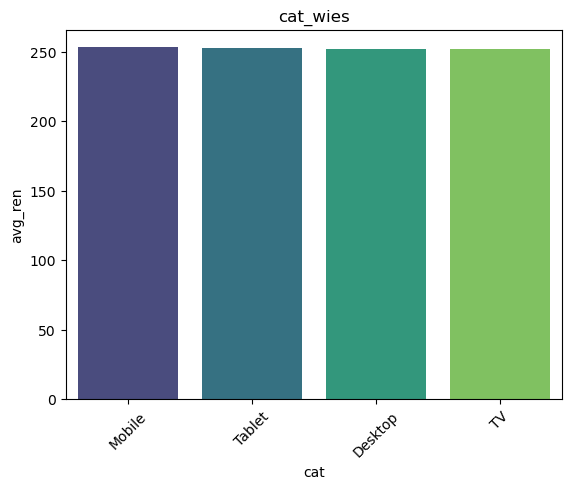

In [25]:
cat_rev = df.groupby('device')['ad_revenue_usd'].mean().sort_values(ascending=False)
sns.barplot(x=cat_rev.index,y=cat_rev.values,palette='viridis')
plt.title("cat_wies")
plt.xlabel('cat')
plt.ylabel('avg_ren')
plt.xticks(rotation =45)
plt.show()

In [26]:
df.head(2)

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,...,month,day,watch_revenue_interaction,like_rate,log_views,log_likes,log_comments,log_ad_revenue_usd,month_sin,month_cos
0,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,...,9,24,5.383657e+06,0.122874,9.204020,7.108244,5.771441,5.318993,-1.0,-1.836970e-16
1,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,...,9,22,2.142757e+06,0.064085,9.212139,6.466145,5.849325,4.954985,-1.0,-1.836970e-16


In [27]:
print(df.columns.tolist())

['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'category', 'device', 'country', 'ad_revenue_usd', 'year', 'month', 'day', 'watch_revenue_interaction', 'like_rate', 'log_views', 'log_likes', 'log_comments', 'log_ad_revenue_usd', 'month_sin', 'month_cos']


In [ ]:
 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

In [29]:
# Step 1: Feature Engineering
df['log_ad_revenue_usd'] = np.log1p(df['ad_revenue_usd'])
df['like_rate'] = df['likes'] / (df['views'] + 1)
df['comment_rate'] = df['comments'] / (df['views'] + 1)

for col in ['views', 'likes', 'comments']:
    df[f'log_{col}'] = np.log1p(df[col])

In [30]:
# Step 2: 5 Features மட்டும்
X = df[['watch_time_minutes',
        'log_likes',
        'like_rate',
        'video_length_minutes',
        'log_views']]
print(X.head(2))

   watch_time_minutes  log_likes  like_rate  video_length_minutes  log_views
0        26497.214184   7.108244   0.122874              2.862137   9.204020
1        15209.747445   6.466145   0.064085             23.738069   9.212139


In [31]:
y = df['log_ad_revenue_usd']

# Step 3: Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
# ✅ Step 4: Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
# ✅ Step 5: Train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [34]:
# ✅ Step 6: Evaluate
y_pred = model.predict(X_test_scaled)
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

In [35]:
print(f'MAE  : {mean_absolute_error(y_test_actual, y_pred_actual):.2f}')
print(f'R²   : {r2_score(y_test_actual, y_pred_actual):.4f}')


MAE  : 5.25
R²   : 0.9437


In [36]:



# Step 6: Save
joblib.dump(model, 'final_ads_revenue_model.pkl')
print("Model Saved! ✅")

Model Saved! ✅


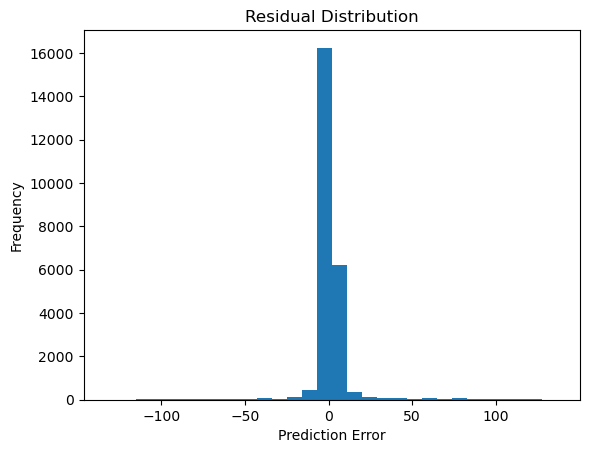

In [37]:
residuals = y_test_actual - y_pred_actual

import matplotlib.pyplot as plt

plt.hist(residuals, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

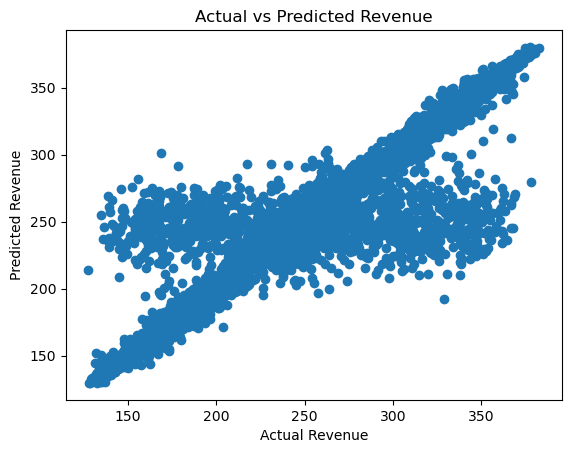

In [38]:
plt.scatter(y_test_actual, y_pred_actual)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")
plt.show()

In [47]:
print(f'MAE  : {mean_absolute_error(y_test_actual, y_pred_actual):.2f}')
print(f'R²   : {r2_score(y_test_actual, y_pred_actual):.4f}')


MAE  : 5.05
R²   : 0.9458


In [39]:
print(residuals.describe())

count    24480.000000
mean         0.445643
std         14.680860
min       -132.900446
25%         -2.050125
50%          0.092387
75%          2.217938
max        136.514834
Name: log_ad_revenue_usd, dtype: float64


In [40]:
print(df['ad_revenue_usd'].describe())

count    122400.000000
mean        252.727210
std          61.957052
min         126.590603
25%         199.902018
50%         252.749699
75%         305.597518
max         382.768254
Name: ad_revenue_usd, dtype: float64


                feature  importance
0    watch_time_minutes    0.940341
1             log_likes    0.024259
2             like_rate    0.012953
3  video_length_minutes    0.011881
4             log_views    0.010567


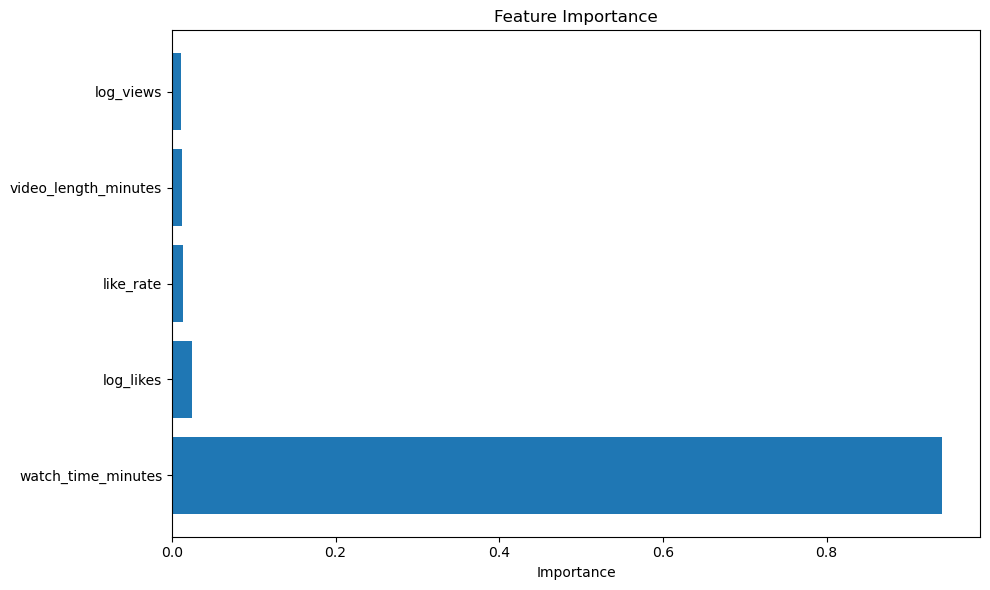

In [41]:
import matplotlib.pyplot as plt

# Feature Importance எடுக்கோம்
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance)

# Graph போடோம்
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], 
         feature_importance['importance'])
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [42]:
!pip install xgboost

In [43]:
import sys
!{sys.executable} -m pip install xgboost

In [44]:
import xgboost
print(xgboost.__version__)

3.2.0


In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
import xgboost as xgb
from xgboost import XGBRegressor
import joblib

# ✅ Step 1: Feature Engineering
df['log_ad_revenue_usd'] = np.log1p(df['ad_revenue_usd'])
df['like_rate'] = df['likes'] / (df['views'] + 1)

for col in ['views', 'likes']:
    df[f'log_{col}'] = np.log1p(df[col])

# ✅ Step 2: Features & Target
X = df[['watch_time_minutes',
        'log_likes',
        'like_rate',
        'video_length_minutes',
        'log_views']]

y = df['log_ad_revenue_usd']

# ✅ Step 3: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ✅ Step 4: Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ✅ Step 5: XGBoost Train
model_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
model_xgb.fit(X_train_scaled, y_train)

# ✅ Step 6: Evaluate
y_pred = model_xgb.predict(X_test_scaled)
y_pred_actual = np.expm1(y_pred)
y_test_actual = np.expm1(y_test)

print(f'MAE  : {mean_absolute_error(y_test_actual, y_pred_actual):.2f}')
print(f'R²   : {r2_score(y_test_actual, y_pred_actual):.4f}')

# ✅ Step 7: Save
joblib.dump(model_xgb, 'final_ads_revenue_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("XGBoost Model Saved! ✅")

MAE  : 5.05
R²   : 0.9458
XGBoost Model Saved! ✅


In [48]:
import os
size = os.path.getsize('final_ads_revenue_model.pkl')
print(f"Model size: {size / 1024 / 1024:.2f} MB")

Model size: 0.46 MB
